<a href="https://colab.research.google.com/github/kyuho11488/kyuho11488/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_10%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C_2021148025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

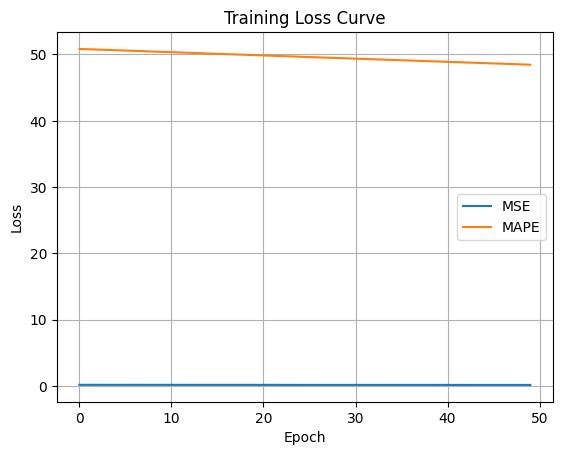

In [21]:
# MLP for numpy
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성하기
np.random.seed(0)
n = 1000 # 샘플 개수
x1, x2 = np.random.rand(2, n) # 입력 feature 2개 (x1, x2) 선언하기
X = np.column_stack((x1, x2)) # (1000, 2) 형태로 입력 병합하기
# 타겟값 생성 (비선형 회귀 -> 시그모이드 함수로 변환하기)
y = 1 / (1 + np.exp(-(2 * x1 + 3 * x2 - 1))) # 타켓 sigmoid + clip 보정하기(MAPE 안정화하기, 선형 조합 후 sigmoid 작용하기)
y = np.clip(y, 0.1, 0.9) # 0.1~0.9 사이로 제한하기(MAPE 오류 방지용, 0 근처 값 방지하기 -> MAPE 계산 안정화하기)

# 시그모이드 함수 및 도함수 정의하기 (forward, backward 계산용)
sigmoid = lambda z : 1 / (1 + np.exp(-z)) # 시그모이드 함수 정의하기
d_sigmoid = lambda z : sigmoid(z) * (1 - sigmoid(z)) # derivation 시그모이드 함수 정의하기

# 신경망 가중치 및 편향 초기화하기 (은닉층 3개 뉴런, 출력층 1개)
w1, b1 = np.random.randn(2, 3), np.zeros((1, 3)) # 입력층 -> 은닉층
w2, b2 = np.random.randn(3, 1), np.zeros((1, 1)) # 은닉층 -> 입력층
lr, epochs = 0.01, 50 # 학습률(learning rate) 0.01으로 선언하기, 에폭(epochs)을 50으로 선언하기
mse_list, mape_list = [], [] # 손실 추적용 리스트 선언하기

# 학습 반복하기(에폭마다 순전파 -> 손실 계산 -> 역전파 -> 가중치 업데이트하기)
for _ in range(epochs):
  # 순전파 (Forward Pass)
  Z1 = X @ w1 + b1 # 은닉층 선형 조합
  H = sigmoid(Z1) # 은닉층 활성화하기
  Z2 = H @ w2 + b2 # 출력층 선형 조합
  y_hat = sigmoid(Z2).flatten() # 출력층 활성화 및 차원 축소하기

  # 손실 함수 계산하기(MSE, MAPE)
  mse = np.mean((y_hat - y) ** 2) # 평균 제곱 오차
  epsilon = 1e-8
  mape = np.mean(np.abs((y_hat - y) / (y + epsilon))) * 100 # 평균 절대 백분율 오차
  mse_list.append(mse)
  mape_list.append(mape)

  # 역전파 (Backward Pass)
  dZ2 = (y_hat - y) * d_sigmoid(Z2).flatten() # 출력층 오차
  dZ2 = dZ2[:, None] # 차원 맞춤
  w2 -= lr * H.T @ dZ2 / n # 출력층 가중치 업데이트하기
  b2 -= lr * dZ2.mean(0, keepdims = True)

  dZ1 = dZ2 @ w2.T * d_sigmoid(Z1) # 은닉층 오차
  w1 -= lr * X.T @ dZ1 / n # 은닉층 가중치 업데이트하기
  b1 -= lr * dZ1.mean(0, keepdims = True)

 # 시각화하기(그래프 출력하기)
plt.plot(mse_list, label ="MSE")
plt.plot(mape_list, label ="MAPE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

그래프 설명하기

1. MSE(파란선) : 0.01 미만에서 안정적으로 작아집니다.

2. MAPE(주황선) : 50% 근처에서 시작해 아주 천천히 감소합니다. -> 여전히 좀 높은 편입니다.

* MAPE가 여전히 높은 이유 : 예측 정확도 자체가 아주 높은 모델이 아니기 때문입니다.